In [26]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
sns.set_theme()

In [27]:
df = pd.read_excel('data/Training.xlsx', parse_dates=['Completion Date', 'Match Activation Date'])

In [28]:
df.head()

,Match ID 18Char,Completion Date,Match Support Contact Notes,Stage,Little ID,Big ID,Big County,Big Age,Big Occupation,Big: Military,...,Little Contact: Interest Finder - Career,Little Contact: Interest Finder - Personality,Little Contact: Interest Finder - Three Wishes,Little Gender,Little Participant: Race/Ethnicity,Little Birthdate,Little Mailing Address Census Block Group,Big Home Census Block Group,Big Employer/School Census Block Group,Match Length
0,a1v2J0000028pRvQAI,2017-11-30,Question: Activities: Answer: See ms...,Closed,0032J00003PLe29QAD,0032J00003PhDOI,Hennepin,40,Unemployed,NaN,...,NaN,NaN,NaN,Female,Black or African American,2004-01-01,2.705303e+11,2.705302e+11,NaN,9.0
1,a1v2J0000028pRvQAI,2017-10-31,Question: Activities: Answer: See MS...,Closed,0032J00003PLe29QAD,0032J00003PhDOI,Hennepin,40,Unemployed,NaN,...,NaN,NaN,NaN,Female,Black or African American,2004-01-01,2.705303e+11,2.705302e+11,NaN,9.0
2,a1v2J0000028pRvQAI,2017-12-01,Question: Activities: Answer: Match ...,Closed,0032J00003PLe29QAD,0032J00003PhDOI,Hennepin,40,Unemployed,NaN,...,NaN,NaN,NaN,Female,Black or African American,2004-01-01,2.705303e+11,2.705302e+11,NaN,9.0
3,a1v2J0000028pRvQAI,2017-05-29,Question: Activities: Answer: Msc as...,Closed,0032J00003PLe29QAD,0032J00003PhDOI,Hennepin,40,Unemployed,NaN,...,NaN,NaN,NaN,Female,Black or African American,2004-01-01,2.705303e+11,2.705302e+11,NaN,9.0
4,a1v2J0000028pRvQAI,2017-04-30,Question: Activities: Answer: Msc as...,Closed,0032J00003PLe29QAD,0032J00003PhDOI,Hennepin,40,Unemployed,NaN,...,NaN,NaN,NaN,Female,Black or African American,2004-01-01,2.705303e+11,2.705302e+11,NaN,9.0


In [83]:
# df_static contains only one row for each match without the time dependent data from each match
df_static = df.drop(['Completion Date', 'Match Support Contact Notes' ], axis=1)
df_static = df_static.drop_duplicates()
df_static = df_static[df_static['Match Length'].notna()]
df_static.head()

,Match ID 18Char,Stage,Little ID,Big ID,Big County,Big Age,Big Occupation,Big: Military,Big Approved Date,Big Level of Education,...,Little Contact: Interest Finder - Career,Little Contact: Interest Finder - Personality,Little Contact: Interest Finder - Three Wishes,Little Gender,Little Participant: Race/Ethnicity,Little Birthdate,Little Mailing Address Census Block Group,Big Home Census Block Group,Big Employer/School Census Block Group,Match Length
0,a1v2J0000028pRvQAI,Closed,0032J00003PLe29QAD,0032J00003PhDOI,Hennepin,40,Unemployed,NaN,NaT,Masters Degree,...,NaN,NaN,NaN,Female,Black or African American,2004-01-01,2.705303e+11,2.705302e+11,NaN,9.0
10,a1v2J000002uR0JQAU,Closed,0032J00003PfZ6OQAV,0032J00003PgoV1,Washington,65,Tech: Research/Design,NaN,2018-04-11,NaN,...,NaN,NaN,NaN,Female,Black or African American; White or Caucasian,2006-06-01,2.716307e+11,2.716307e+11,NaN,46.1
30,a1v2J0000027NsOQAU,Closed,0032J00003PLeoRQAT,0032J00003Ph0MT,Ramsey,45,Military,NaN,NaT,Bachelors Degree,...,NaN,NaN,NaN,Male,Black or African American; White or Caucasian,2007-01-01,2.700305e+11,2.712304e+11,NaN,6.2
36,a1v2J0000027dtOQAQ,Active,0032J00003PLeoRQAT,0032J00003Ph14N,Hennepin,61,Finance: Banking,NaN,2018-01-02,NaN,...,NaN,NaN,NaN,Male,Black or African American; White or Caucasian,2007-01-01,2.700305e+11,NaN,NaN,85.6
72,a1v2J0000028enKQAQ,Closed,0032J00003PfZ6QQAV,0032J00003Ph14j,Ramsey,29,Human Services: Non-Profit,NaN,2018-03-12,Bachelors Degree,...,NaN,NaN,NaN,Female,Hispanic,2005-01-01,2.716307e+11,2.705311e+11,NaN,28.3


## Response Variables: Match Length, Closure Reason

### Q1: Analyze distribution of response variables

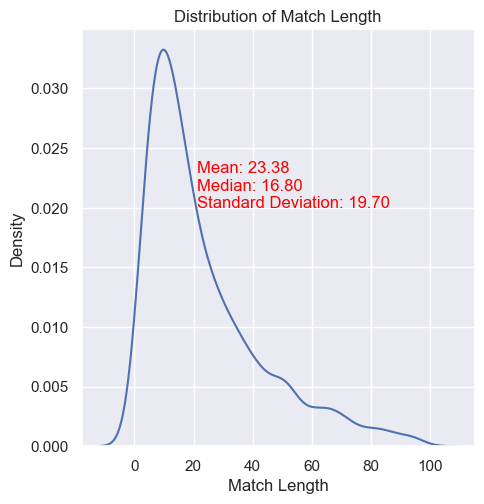

In [84]:
sns.displot(data=df_static, x='Match Length', kind='kde')
mean_match = df_static['Match Length'].mean()
median_match = df_static['Match Length'].median()
std_match = df_static['Match Length'].std()

s = f"Mean: {mean_match:.2f}\nMedian: {median_match:.2f}\nStandard Deviation: {std_match:.2f}"
plt.text(x=21, y=0.02, s=s, fontsize=12, color='red')
plt.title("Distribution of Match Length")
plt.show()

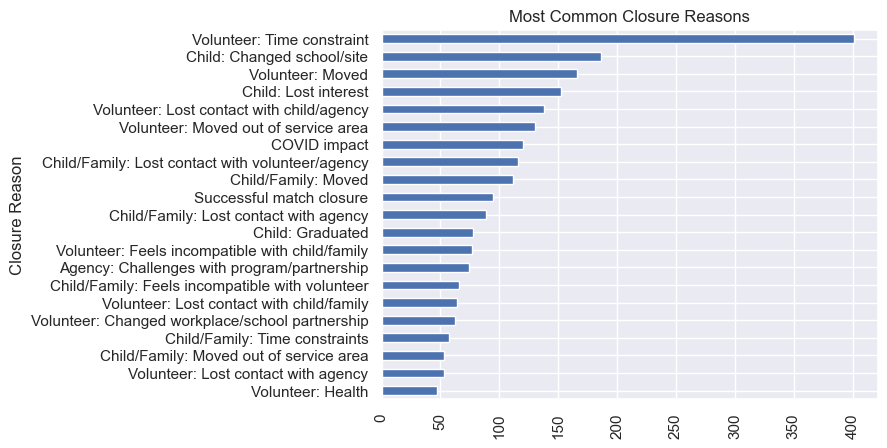

In [31]:
X = df_static[df_static['Closure Reason'].notna()]['Closure Reason'].value_counts().sort_values()
X[X>40].plot(kind='barh')
plt.xticks(rotation=90)
plt.title("Most Common Closure Reasons")
plt.show()

### Q1: Change of Response Variables with Program type

In [32]:
df_static[df_static['Program'].notna()]['Program'].value_counts()

Program
General Community                          1727
Virtual Match                               443
School-Based Program                        326
NAZ Zip Code                                 97
General Site                                 83
St Thomas/Four Seasons                       71
NAZ Match                                    56
BSW-Cargill                                  55
Grad Coach-Henry High School                 49
BSW-General Mills                            47
BSW-Carlson                                  41
Macalester/Dayton's Bluff                    39
YIP 2018                                     34
GRU Match                                    33
YIP 2019                                     32
Sports Buddies Cohorts 1/2 - 2023-24         31
BSW-Comcast                                  16
YIP 2016                                     13
Grad Coach-Edison High School                11
Weaver Elementary-Maplewood PD                9
STEM Cohort 2025                

Plotting the match length distribution of the top 9 programs by enrollment count

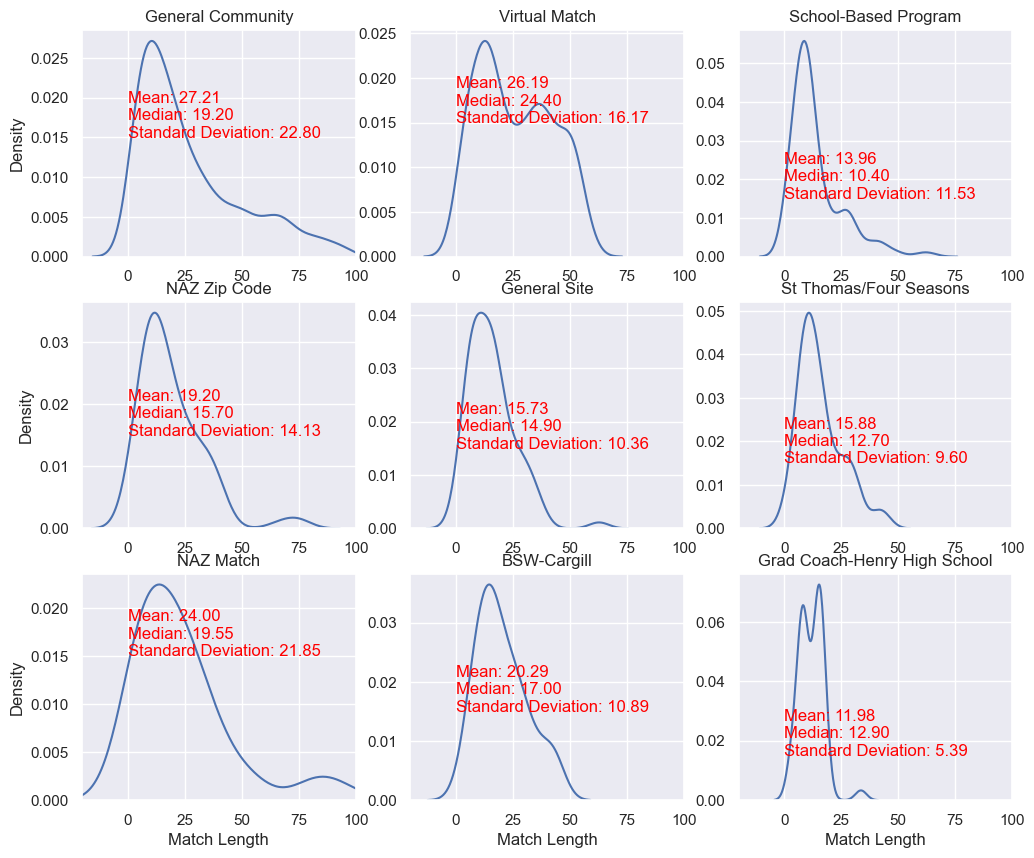

In [85]:
fig, ax = plt.subplots(3,3, figsize=(12,10))
top_programs = df_static[df_static['Program'].notna()]['Program'].value_counts().index[:9].to_list()

for i in range(3):
    for j in range(3):
        p = top_programs.pop(0)
        sns.kdeplot(data=df_static[df_static['Program'] == p], x='Match Length', ax=ax[i, j])
        mean_match = df_static[df_static['Program'] == p]['Match Length'].mean()
        median_match = df_static[df_static['Program'] == p]['Match Length'].median()
        std_match = df_static[df_static['Program'] == p]['Match Length'].std()

        s = f"Mean: {mean_match:.2f}\nMedian: {median_match:.2f}\nStandard Deviation: {std_match:.2f}"
        ax[i, j].text(x=0, y=0.015, s=s, fontsize=12, color='red')
        ax[i, j].set_xlim(-20, 100)
        if i in [0, 1]:
            ax[i,j].set_xlabel(None)
        if j in [1, 2]:
            ax[i, j].set_ylabel(None)
        ax[i, j].set_title(f'{p}')
plt.show()

### Response Variable distribution change over time

In [86]:
df_static['Activation Year'] = df_static['Match Activation Date'].dt.year

In [87]:
df_static.groupby(['Activation Year'])['Match Length'].agg(['mean', 'std'])

,mean,std
Activation Year,,
2017,26.840407,24.543497
2018,26.397306,22.551974
2019,27.575548,19.145636
2020,26.913158,18.276446
2021,26.884783,15.127184
2022,19.306667,11.198833
2023,15.386348,6.489587
2024,7.191824,3.536425


A plot of match length by activation year below. Error bars show 1/2 standard deviation. Of course average match length decreases in later years so this doesnt seem to change much with time. 

Text(0.5, 1.0, 'Match Length by Activation Year')

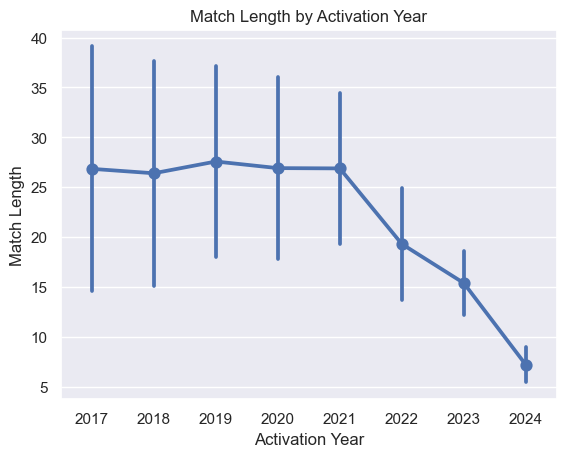

In [88]:
sns.pointplot(data=df_static, x='Activation Year', y='Match Length', errorbar=('sd', 0.5))
plt.title('Match Length by Activation Year')

There is change in the shape of the distribution over time, but we should probably chalk this up to the fact that the match length can not be too long for recent activation years. The general tendency is a unimodal distribution with a fat right tail. 

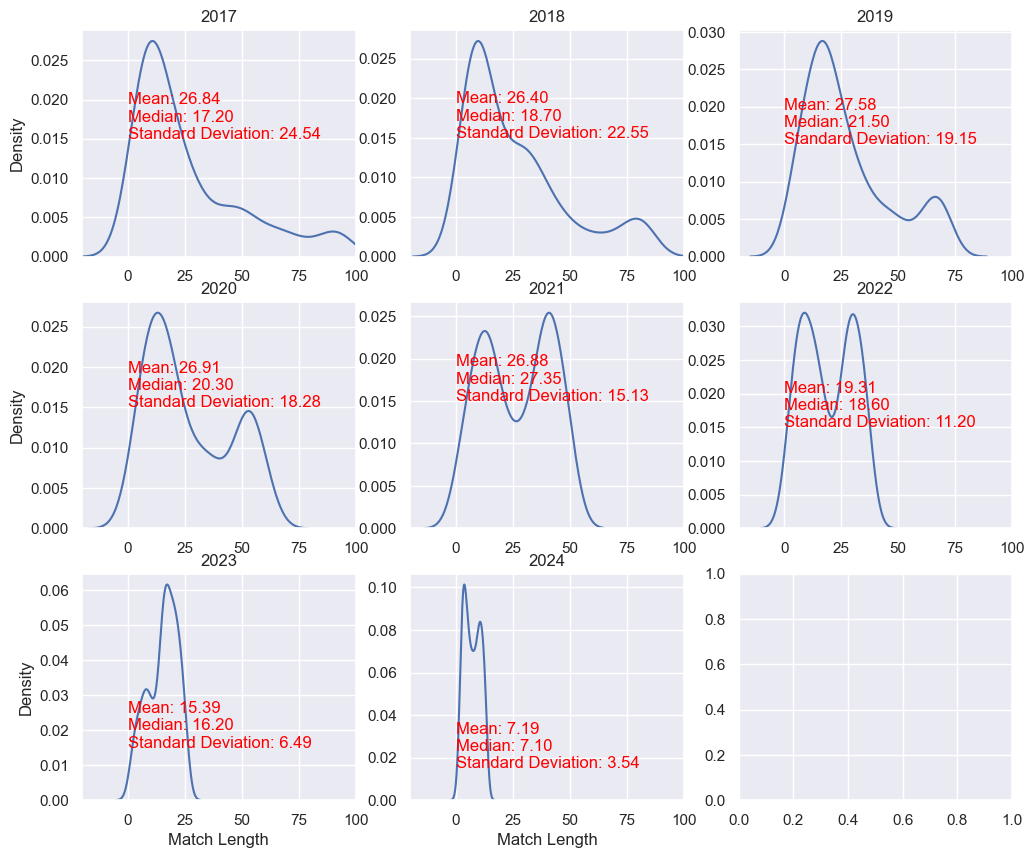

In [89]:
fig, ax = plt.subplots(3,3, figsize=(12,10))
years = [2017 + i for i in range(8)]

for i in range(3):
    for j in range(3):
        if not years:
            break
        p = years.pop(0)
        sns.kdeplot(data=df_static[df_static['Activation Year'] == p], x='Match Length', ax=ax[i, j])
        mean_match = df_static[df_static['Activation Year'] == p]['Match Length'].mean()
        median_match = df_static[df_static['Activation Year'] == p]['Match Length'].median()
        std_match = df_static[df_static['Activation Year'] == p]['Match Length'].std()

        s = f"Mean: {mean_match:.2f}\nMedian: {median_match:.2f}\nStandard Deviation: {std_match:.2f}"
        ax[i, j].text(x=0, y=0.015, s=s, fontsize=12, color='red')
        ax[i, j].set_xlim(-20, 100)
        if i in [0, 1]:
            ax[i,j].set_xlabel(None)
        if j in [1, 2]:
            ax[i, j].set_ylabel(None)
        ax[i, j].set_title(f'{p}')
plt.show()

Checking for possible seasonality?

In [90]:
df_static['Activation Month'] = df_static['Match Activation Date'].dt.month

Maybe matches that start in the summer are slightly more favorable? I am excluding recently activated matches here. A lot more data for later months

In [91]:
df_static[df_static['Activation Year'] <= 2021].groupby(['Activation Month'])['Match Length'].agg(['count', 'mean', 'std'])

,count,mean,std
Activation Month,,,
1,195,27.367179,21.855181
2,239,26.264854,22.802840
3,204,25.425980,22.872938
4,180,31.238889,24.301864
5,151,32.536424,25.311946
6,154,31.021429,22.643015
7,158,29.589241,21.942759
8,145,29.262069,21.554727
9,147,29.344218,20.659802


Text(0.5, 1.0, 'Match Length by Activation Month')

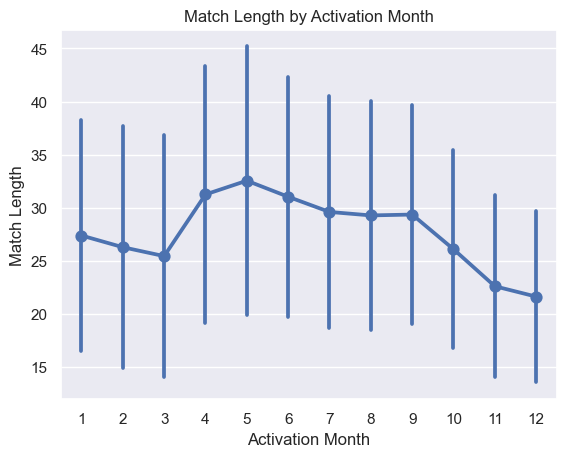

In [49]:
sns.pointplot(data=df_static[df_static['Activation Year'] <= 2021], x='Activation Month', y='Match Length', errorbar=('sd', 0.5))
plt.title('Match Length by Activation Month')

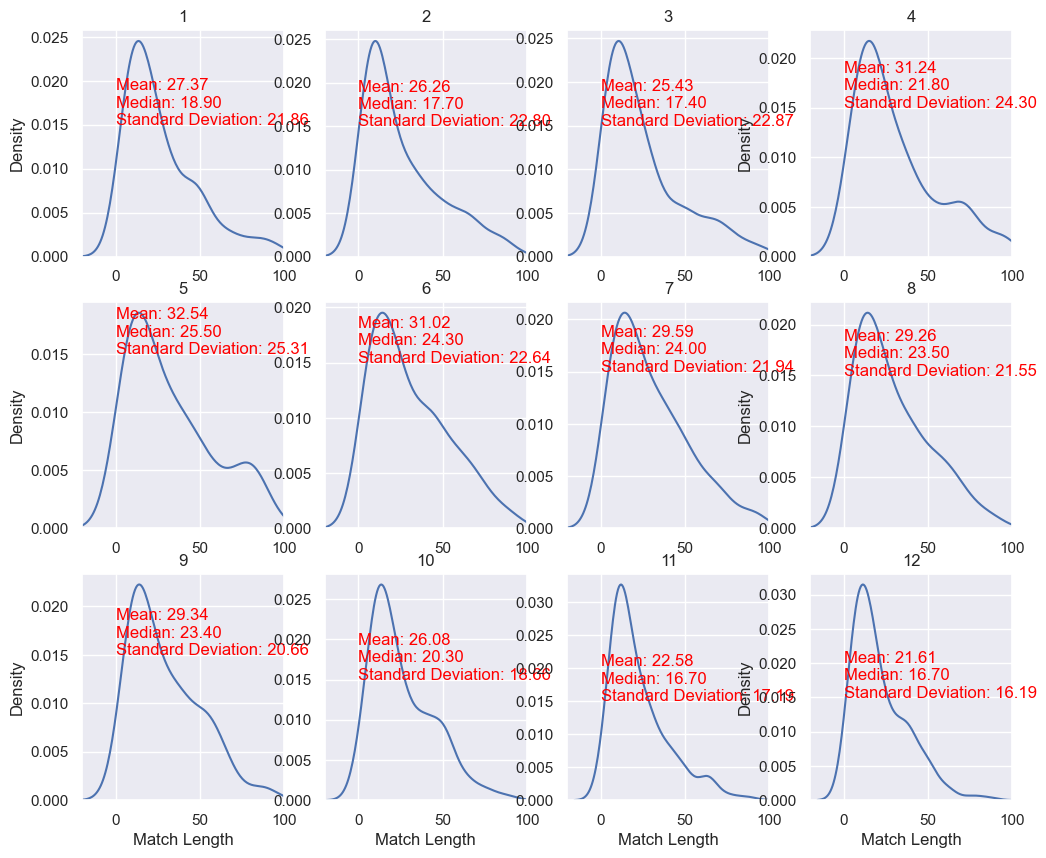

In [92]:
fig, ax = plt.subplots(3,4, figsize=(12,10))
months = [i + 1 for i in range(12)]
df_static_early = df_static[df_static['Activation Year'] <= 2021]
for i in range(3):
    for j in range(4):
        p = months.pop(0)
        sns.kdeplot(data=df_static_early[df_static_early['Activation Month'] == p], x='Match Length', ax=ax[i, j])
        mean_match = df_static_early[df_static_early['Activation Month'] == p]['Match Length'].mean()
        median_match = df_static_early[df_static_early['Activation Month'] == p]['Match Length'].median()
        std_match = df_static_early[df_static_early['Activation Month'] == p]['Match Length'].std()

        s = f"Mean: {mean_match:.2f}\nMedian: {median_match:.2f}\nStandard Deviation: {std_match:.2f}"
        ax[i, j].text(x=0, y=0.015, s=s, fontsize=12, color='red')
        ax[i, j].set_xlim(-20, 100)
        if i in [0, 1]:
            ax[i,j].set_xlabel(None)
        if j in [1, 2]:
            ax[i, j].set_ylabel(None)
        ax[i, j].set_title(f'{p}')
plt.show()

There's essentially no difference. Credit Deepseek for the below code. Of course there is an outlier for match closure due to covid for those started in 2019

/var/folders/6w/wlp431zj1mg9m90s_c24hkvm0000gn/T/ipykernel_10132/3816900107.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_per_year = counts.groupby(['Activation Year']).apply(


<Figure size 1200x600 with 0 Axes>

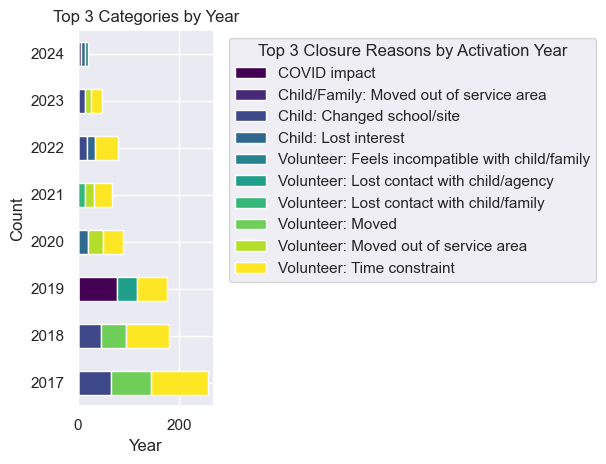

In [93]:
# Group by year and category, then count occurrences
counts = df_static.groupby(['Activation Year', 'Closure Reason']).size().reset_index(name='count')
    
# Get top 3 categories for each year
top3_per_year = counts.groupby(['Activation Year']).apply(
    lambda x: x.nlargest(3, 'count')).reset_index(drop=True)
    
# Pivot for easier plotting
pivot_df = top3_per_year.pivot(index='Activation Year', columns='Closure Reason', values='count')
    
    # Plotting
plt.figure(figsize=(12, 6))
pivot_df.plot(kind='barh', stacked=True, colormap='viridis')
plt.title('Top 3 Categories by Year')
plt.ylabel('Count')
plt.xlabel('Year')
plt.legend(title='Top 3 Closure Reasons by Activation Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Distribution by categorical variable agreement. Race and gender agreement have negligible effect

In [94]:
df_static['Big Race/Ethnicity'].head()

0     Black or African American;White or Caucasian;
10                              White or Caucasian;
30                                           Asian;
36                              White or Caucasian;
72                              White or Caucasian;
Name: Big Race/Ethnicity, dtype: object

In [105]:
df_static['Gender Agreement'] = df_static['Big Gender'] == df_static['Little Gender']
df_static['Race Agreement'] = df_static['Big Race/Ethnicity'].str.rstrip(';') == df_static['Little Participant: Race/Ethnicity']

<Axes: xlabel='Gender Agreement', ylabel='Match Length'>

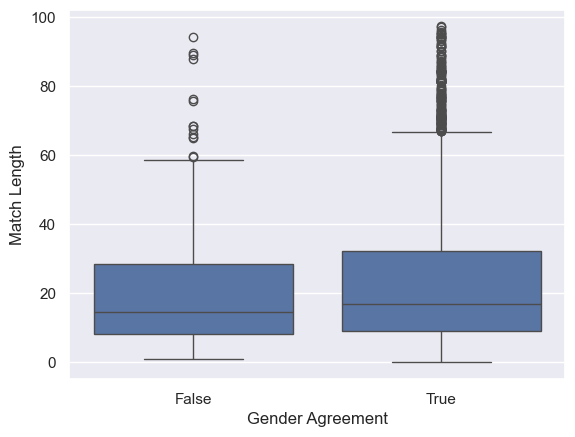

In [106]:
sns.boxplot(data=df_static, x='Gender Agreement', y='Match Length')

<Axes: xlabel='Race Agreement', ylabel='Match Length'>

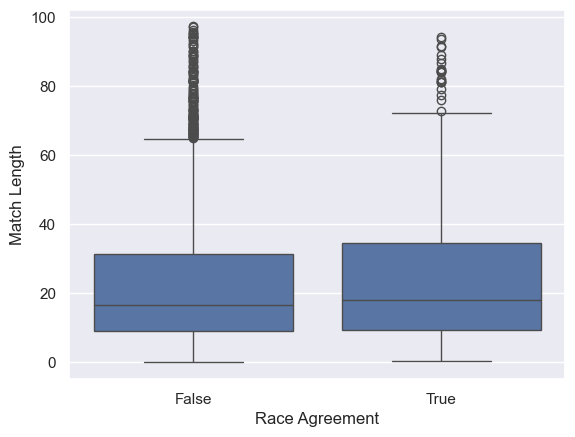

In [107]:
sns.boxplot(data=df_static, x='Race Agreement', y='Match Length')

/var/folders/6w/wlp431zj1mg9m90s_c24hkvm0000gn/T/ipykernel_10132/3507201268.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_per_year = counts.groupby(['Gender Agreement']).apply(


<Figure size 1200x600 with 0 Axes>

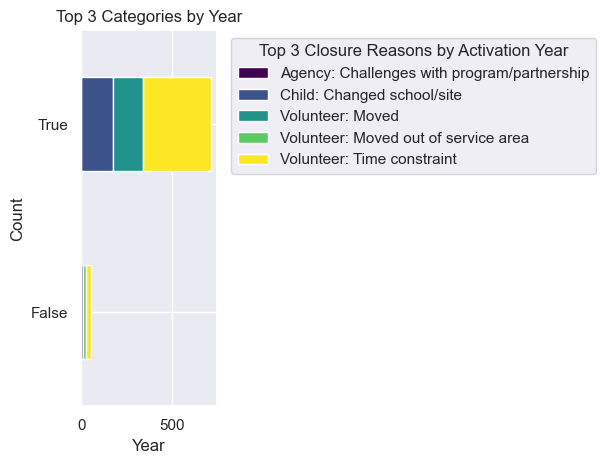

In [ ]:
counts = df_static.groupby(['Gender Agreement', 'Closure Reason']).size().reset_index(name='count')
    
# Get top 3 categories for each year
top3_per_year = counts.groupby(['Gender Agreement']).apply(
    lambda x: x.nlargest(3, 'count')).reset_index(drop=True)
    
# Pivot for easier plotting
pivot_df = top3_per_year.pivot(index='Gender Agreement', columns='Closure Reason', values='count')
    
    # Plotting
plt.figure(figsize=(12, 6))
pivot_df.plot(kind='barh', stacked=True, colormap='viridis')
plt.title('Top 3 Closure Reasons by Gender Agreement')
plt.ylabel('Count')
plt.xlabel('Year')
plt.legend(title='Top 3 Closure Reasons by Gender Agreement', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/6w/wlp431zj1mg9m90s_c24hkvm0000gn/T/ipykernel_10132/1796939710.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_per_year = counts.groupby(['Race Agreement']).apply(


<Figure size 1200x600 with 0 Axes>

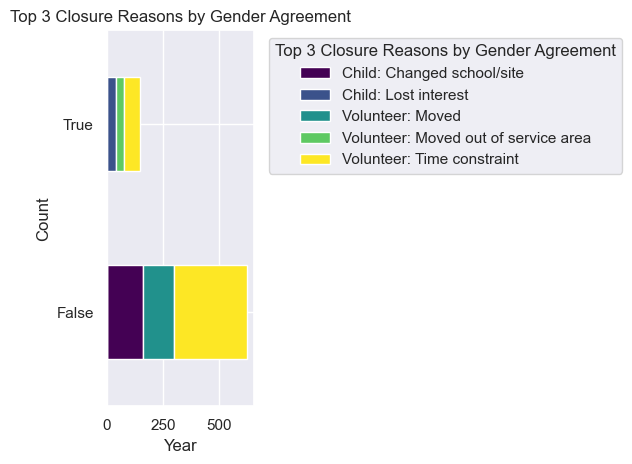

In [ ]:
counts = df_static.groupby(['Race Agreement', 'Closure Reason']).size().reset_index(name='count')
    
# Get top 3 categories for each year
top3_per_year = counts.groupby(['Race Agreement']).apply(
    lambda x: x.nlargest(3, 'count')).reset_index(drop=True)
    
# Pivot for easier plotting
pivot_df = top3_per_year.pivot(index='Race Agreement', columns='Closure Reason', values='count')
    
    # Plotting
plt.figure(figsize=(12, 6))
pivot_df.plot(kind='barh', stacked=True, colormap='viridis')
plt.title('Top 3 Closure Reasons by Race Agreement')
plt.ylabel('Count')
plt.xlabel('Year')
plt.legend(title='Top 3 Closure Reasons by Race Agreement', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Super Simple Models

Note that the data im using here doesn't contain the match support contact notes or any time depenent data. Only one row for each match with just static data. 

In [113]:
import sklearn as sk
from sklearn.model_selection import train_test_split
import scipy.stats as st
from sklearn.metrics import root_mean_squared_error

### Poisson Model

In [126]:
class PoissonModel:
    
    def __init__(self):
        self.mean = None
        self.rv = None

    def fit(self, X):
        self.mean = np.mean(X)
        self.rv = st.poisson(self.mean)
    
    def predict(self, X):
        return self.rv.rvs(size=(X.shape[0], ))


In [127]:
df_static_train, df_static_test = train_test_split(df_static, test_size=0.2, shuffle=True, random_state=4)

In [139]:
model = PoissonModel()
model.fit(df_static_train['Match Length'])

In [145]:
y_test = model.predict(df_static_test)

In [141]:
df_static_test.shape

(655, 71)

In [146]:
print(root_mean_squared_error(y_test, df_static_test['Match Length']))

20.330883513204263


## Gaussian Model

In [134]:
class GaussianModel:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        self.mean = X.mean()
        self.std = X.std()

    def predict(self, X):
        m = X.shape[0]
        return np.random.normal(loc=self.mean, scale=self.std, size=(m,))

In [138]:
model = GaussianModel()
model.fit(df_static_train['Match Length'])
y_test = model.predict(df_static_test)
print(root_mean_squared_error(y_test, df_static_test['Match Length']))

28.593156613415424


Poisson is better than Gaussian!

Running the tree based model like last time but without the time dependent data

In [147]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

In [148]:
def preprocess(data_frame: pd.DataFrame): 

    target = 'Match Length'

    df_processed = data_frame[data_frame[target].notna() & (data_frame[target] > 0)]

    features = df_processed.drop(columns=[
        target, 'Match ID 18Char', 'Closure Details',
        'Rationale for Match', 'Big Contact: Preferred Communication Type',
        'Big Contact: Former Big/Little', 'Big Contact: Interest Finder - Sports',
        'Big Contact: Interest Finder - Places To Go', 'Big Contact: Interest Finder - Hobbies',
        'Big Contact: Interest Finder - Entertainment', 'Big Contact: Created Date'
    ])

    return df_processed, features, target

In [158]:
def get_preprocessor(features: pd.DataFrame, sparse=True):

    cat_cols = features.select_dtypes(include=['object', 'category', 'bool']).columns
    num_cols = features.select_dtypes(include=['int64', 'float64']).columns

    constant_filter = VarianceThreshold(threshold=0)
    constant_filter.fit(features[num_cols])
    non_constant_num = num_cols[constant_filter.get_support()]

    preprocessor = ColumnTransformer(
        transformers=[('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), non_constant_num),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', max_categories=20, sparse_output=sparse))
        ]), cat_cols)
        ],
        remainder='drop'
    )

    return preprocessor

In [160]:
df_processed, features, target = preprocess(df_static)
print(df_processed.columns)
preprocessor = get_preprocessor(features)

model = Pipeline([('preprocess', preprocessor), 
                  ('random_forest', RandomForestRegressor(min_samples_leaf=5, n_estimators=100, random_state=72, n_jobs=-1))
                  ])
X = df_processed[features.columns]
y = df_processed[target]

Index(['Match ID 18Char', 'Stage', 'Little ID', 'Big ID', 'Big County',
       'Big Age', 'Big Occupation', 'Big: Military', 'Big Approved Date',
       'Big Level of Education', 'Big Languages', 'Big Gender',
       'Big Birthdate', 'Big Employer', 'Program', 'Program Type',
       'Big Race/Ethnicity', 'Closure Reason', 'Closure Details',
       'Match Activation Date', 'Match Closure Meeting Date',
       'Rationale for Match', 'Big Enrollment: Record Type',
       'Big Assessment Uploaded', 'Big Acceptance Date', 'Big Car Access',
       'Big Days Acceptance to Match', 'Big Days Interview to Acceptance',
       'Big Days Interview to Match', 'Big Open to Cross-Gender Match',
       'Big Re-Enroll', 'Big Contact: Preferred Communication Type',
       'Big Contact: Former Big/Little',
       'Big Contact: Interest Finder - Sports',
       'Big Contact: Interest Finder - Places To Go',
       'Big Contact: Interest Finder - Hobbies',
       'Big Contact: Interest Finder - Entertainmen

In [161]:
kfold = KFold(n_splits=5, shuffle=True, random_state=62)

rmses = []

for i, (train_idx, test_idx) in enumerate(kfold.split(X)):

    print(f'Training fold {i}')
    X_tt = X.iloc[train_idx, :]
    X_val = X.iloc[test_idx, :]
    y_tt = y.iloc[train_idx]
    y_val = y.iloc[test_idx]

    y_pred = model.fit(X_tt, y_tt).predict(X_val)
    rmses.append(root_mean_squared_error(y_pred, y_val))

Training fold 0
Training fold 1
Training fold 2
Training fold 3
Training fold 4


In [162]:
print(rmses)

[12.430455896943728, 11.78047799816968, 12.133297474635683, 11.31836927052121, 11.06899386196575]


In [163]:
print(f'Standard Deviation of Errors: {np.std(rmses):.2f}')

print(f'Mean of Errors: {np.mean(rmses):.2f}')

Standard Deviation of Errors: 0.50
Mean of Errors: 11.75
